# **Model Compression - LSTM**
**Structure of the notebook:**

**Step 1 - Load saved model (lstm_final_model.keras) + test data + scalers (lstm_scaler_X.joblib, lstm_scaler_y.joblib)**

**Step 2 - Baseline reference — RE-MEASURE size/latency/accuracy (not copied from Modelling_LSTM.ipynb's Additional I)**

**Step 3 - Technique 1: Pruning (magnitude-based weight pruning)**

**Step 4 - Evaluate Technique 1 on test**

**Step 5 - Technique 2: Quantization (float32 → int8, likely via TFLite conversion)**

**Step 6 - Evaluate Technique 2 on test**

**Step 7 - Technique 3: Distillation (train a smaller "student" LSTM to mimic the full model's outputs)**

**Step 8 - Evaluate Technique 3 on test**

**Step 9 - Combination — apply the best-combining techniques together:   (Technique 3 (96-unit student) + Technique 2 (dynamic-range int8 quantization))**


**Step 10 - Evaluate Combination on test**

**Step 11 - Summary comparison (table + chart, all 4+ variants)**

**Step 12 - Save final compressed model(s) + written recommendation**

(Remark: Source files are from previous LSTM Modelling outputs.

Files are stored in github: https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main)




In [1]:
# Read the split data, trained LSTM model, and both scalers directly from
# GitHub (public repo, no auth needed); save this notebook's own outputs
# (figures, compressed models, summary) to a local Colab folder.
import os
import pandas as pd
import urllib.request

BASE_URL = "https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main"
PROCESSED_DIR = f"{BASE_URL}/data/processed"   # read: split datasets from the EDA notebook
MODEL_DIR = f"{BASE_URL}/outputs/lstm"         # read: trained model + scalers from the LSTM modelling notebook

OUTPUT_DIR = "outputs/lstm_compression"        # write: this notebook's own figures, models, summary
os.makedirs(OUTPUT_DIR, exist_ok=True)

# keras.models.load_model() and joblib.load() can't read directly from a URL,
# so download the model and both scalers locally first
LOCAL_MODEL_PATH = f"{OUTPUT_DIR}/lstm_final_model.keras"
LOCAL_SCALER_X_PATH = f"{OUTPUT_DIR}/lstm_scaler_X.joblib"
LOCAL_SCALER_Y_PATH = f"{OUTPUT_DIR}/lstm_scaler_y.joblib"

urllib.request.urlretrieve(f"{MODEL_DIR}/lstm_final_model.keras", LOCAL_MODEL_PATH)
urllib.request.urlretrieve(f"{MODEL_DIR}/lstm_scaler_X.joblib", LOCAL_SCALER_X_PATH)
urllib.request.urlretrieve(f"{MODEL_DIR}/lstm_scaler_y.joblib", LOCAL_SCALER_Y_PATH)
print("Downloaded lstm_final_model.keras, lstm_scaler_X.joblib, lstm_scaler_y.joblib")


Downloaded lstm_final_model.keras, lstm_scaler_X.joblib, lstm_scaler_y.joblib


In [2]:
# Import and install
# Run this cell FIRST in any fresh session (after Restart OR after a full disconnect)
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

!pip install tf_keras --quiet
!pip install tensorflow-model-optimization --quiet

import tensorflow as tf
import keras
import tensorflow_model_optimization as tfmot

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"Legacy Keras active: {os.environ.get('TF_USE_LEGACY_KERAS')}")
print(f"TF-MOT: {tfmot.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 9.3 MB/s eta 0:00:00
TensorFlow: 2.20.0
Keras: 3.13.2
Legacy Keras active: 1
TF-MOT: 0.8.1


In [3]:
# Global determinism setup - forces deterministic GPU op implementations
# (unlike tf.random.set_seed() alone, which seeds the RNG but does NOT
# guarantee identical results across runs on GPU/cuDNN). Adopted after
# observing large run-to-run variance in Step 3's pruning fine-tuning.
# Source: EEEM075 Week 4 Lab 7 setup.
import random
import numpy as np

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.config.experimental.enable_op_determinism()

print("Global determinism enabled (default seed=42).")
print("All subsequent steps use this global seed (42) - no per-step overrides.")


Global determinism enabled (default seed=42).
All subsequent steps use this global seed (42) - no per-step overrides.


# **Step 1 - Load saved model + data + scalers**

In [4]:
# Step 1 - Load saved model + data + scalers

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
import joblib
import os

# 1. Load the model under Keras 3 (the version it was saved with) purely to
#    extract its trained weights - Keras 3 reads its own native .keras format
#    fine; the incompatibility is specifically in legacy Keras 2's InputLayer
#    deserialization, not in Keras 3's.
import keras  # standalone Keras 3 package - independent of the TF_USE_LEGACY_KERAS flag
model_keras3 = keras.models.load_model(LOCAL_MODEL_PATH)
saved_weights = model_keras3.get_weights()
print(f"Extracted {len(saved_weights)} weight arrays from the Keras-3-saved file.")

# 2. Rebuild the IDENTICAL architecture using legacy tf.keras (which now resolves
#    to tf_keras under TF_USE_LEGACY_KERAS=1) - this is the version TF-MOT needs
#    to recognize the model's class correctly.
final_lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 20)),   # WINDOW_SIZE=30, n_features=20
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])
final_lstm_model.set_weights(saved_weights)
final_lstm_model.summary()

print(f"\nBuilt under: {tf.keras.__name__ if hasattr(tf.keras, '__name__') else type(tf.keras)}")

# 3. Sanity check: confirm this is the correct, final tuned model, not a stale/
#    wrong version - same discipline as XGBoost compression's Step 1
total_params = final_lstm_model.count_params()
lstm_layer = final_lstm_model.layers[0]
print(f"\nTotal parameters: {total_params:,} (expected: 283,905)")
print(f"LSTM units: {lstm_layer.units} (expected: 256)")
assert total_params == 283905, "Parameter count mismatch - wrong model file?"
assert lstm_layer.units == 256, "LSTM unit count mismatch - wrong model file?"

# 4. Load the scalers fit during Modelling_LSTM.ipynb - MUST reuse these exact
#    scalers (fit on train only) rather than re-fitting, or feature scaling
#    would be inconsistent with what the model was trained on
scaler_X = joblib.load(LOCAL_SCALER_X_PATH)
scaler_y = joblib.load(LOCAL_SCALER_Y_PATH)
print("\nLoaded lstm_scaler_X.joblib, lstm_scaler_y.joblib")

# 5. Load validation + test raw feature data. Both are needed (not just test)
#    because test sequences must borrow their first 29 days of history from
#    the tail of the validation period - matching Modelling_LSTM.ipynb's Step 3
#    windowing exactly (test "loses NONE" of its rows).
val = pd.read_csv(f'{PROCESSED_DIR}/split_val.csv', index_col='date', parse_dates=True)
test = pd.read_csv(f'{PROCESSED_DIR}/split_test.csv', index_col='date', parse_dates=True)

target_col = 'nd_total_mwh'  # matches XGBoost/LSTM modelling notebooks
val_test_combined = pd.concat([val, test])

X_val_test_raw = val_test_combined.drop(columns=[target_col])
y_val_test_raw = val_test_combined[target_col]

# 6. Scale features using the TRAIN-fit scaler (transform only, never re-fit)
X_val_test_scaled = scaler_X.transform(X_val_test_raw)
y_val_test_scaled = scaler_y.transform(y_val_test_raw.values.reshape(-1, 1)).flatten()

n_features = X_val_test_scaled.shape[1]
print(f"\nCombined val+test raw shape: {X_val_test_raw.shape}, features: {n_features}")

# 7. Reconstruct windowed sequences - SAME logic as Modelling_LSTM.ipynb Step 3:
#    window ends ON the target day itself (29 prior days + the target day)
WINDOW_SIZE = 30

def create_sequences(X, y, dates, window_size):
    Xs, ys, ds = [], [], []
    for i in range(window_size - 1, len(X)):
        Xs.append(X[i - window_size + 1:i + 1])
        ys.append(y[i])
        ds.append(dates[i])
    return np.array(Xs), np.array(ys), np.array(ds)

X_val_test_seq, y_val_test_seq, dates_val_test_seq = create_sequences(
    X_val_test_scaled, y_val_test_scaled, val_test_combined.index.values, WINDOW_SIZE
)

# 8. Keep only the sequences whose target date falls within the TEST period -
#    this discards the validation-period sequences, keeping only the ones that
#    borrowed history FROM validation but predict INTO test
test_mask = pd.to_datetime(dates_val_test_seq) >= test.index.min()
X_test_seq = X_val_test_seq[test_mask]
y_test_seq = y_val_test_seq[test_mask]
test_dates_seq = dates_val_test_seq[test_mask]

n_timesteps = X_test_seq.shape[1]

print(f"\nX_test_seq: {X_test_seq.shape}  (expected: (528, 30, {n_features}))")
print(f"Test period: {pd.to_datetime(test_dates_seq).min().date()} to "
      f"{pd.to_datetime(test_dates_seq).max().date()}")
assert X_test_seq.shape[0] == 528, "Test sequence count mismatch - check windowing logic"

# 9. Actual demand values in real MWh (for evaluation later) - inverse-transform now
y_test_actual_mwh = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
print(f"\nReady: X_test_seq {X_test_seq.shape}, y_test_actual_mwh {y_test_actual_mwh.shape}")

Extracted 5 weight arrays from the Keras-3-saved file.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 256)               283648    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense (Dense)               (None, 1)                 257       
                                                                 
Total params: 283905 (1.08 MB)
Trainable params: 283905 (1.08 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Built under: tensorflow.keras

Total parameters: 283,905 (expected: 283,905)
LSTM units: 256 (expected: 256)

Loaded lstm_scaler_X.joblib, lstm_scaler_y.joblib

Combined val+test raw shape: (893, 20), features: 20

X_test_seq: (

In [5]:
# Verify the weight transfer was exact, not just "didn't error"
test_input = np.random.RandomState(42).randn(1, 30, 20).astype('float32')
pred_keras3 = model_keras3.predict(test_input, verbose=0)
pred_legacy = final_lstm_model.predict(test_input, verbose=0)
max_diff = np.max(np.abs(pred_keras3 - pred_legacy))
print(f"\nMax prediction difference (Keras 3 vs. legacy-rebuilt, same weights): {max_diff:.10f}")
assert max_diff < 1e-5, "Weight transfer produced a different model - do not proceed"


Max prediction difference (Keras 3 vs. legacy-rebuilt, same weights): 0.0000000000


# **Step 2 - Baseline reference (RE-MEASURE size/latency/accuracy)**

In [6]:
# Step 2 - Baseline reference (RE-MEASURE size/latency/accuracy)

import time

# 1. Establish the FAIR baseline size: resave this model via the SAME (legacy
#    tf_keras) pathway that every technique below will also use. NOT the size
#    of the original lstm_final_model.keras file - that was saved under Keras 3,
#    before the TF-MOT-required legacy Keras switch, and comparing against it
#    would be comparing two different save formats, not a real compression
#    effect (this exact confound is what corrupted Technique 1's first attempt).
final_lstm_model.save(f'{OUTPUT_DIR}/lstm_baseline_legacy_resave.keras')
baseline_size_kb = os.path.getsize(f'{OUTPUT_DIR}/lstm_baseline_legacy_resave.keras') / 1024

original_keras3_size_kb = os.path.getsize(LOCAL_MODEL_PATH) / 1024
print(f"Original Additional I file (Keras 3 native): {original_keras3_size_kb:.1f} KB "
      f"(informational only - NOT used for compression comparisons)")
print(f"Baseline size (fair, legacy-Keras pathway, used for ALL comparisons below): "
      f"{baseline_size_kb:.1f} KB")

# 2. Accuracy on TEST - using the SAME evaluate-style metrics as XGBoost's
#    compression notebook, for consistency across both compression writeups
y_pred_scaled = final_lstm_model.predict(X_test_seq, verbose=0).flatten()
y_pred_mwh = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

baseline_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_mwh)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_mwh) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_mwh) / y_test_actual_mwh)) * 100
}
print(f"\nTest MAE:   {baseline_metrics['mae']:,.0f}  (Additional I reference: 14,854)")
print(f"Test RMSE:  {baseline_metrics['rmse']:,.0f}  (Additional I reference: 19,236)")
print(f"Test MAPE:  {baseline_metrics['mape']:.2f}%  (Additional I reference: 2.39%)")

# 3. Inference latency - median-of-several-attempts from the start, given what
#    XGBoost's compression notebook taught us about single-reading noise.
def measure_lstm_inference(model, X, n_repeats=10, n_attempts=5):
    timings = []
    for _ in range(n_attempts):
        start = time.time()
        for _ in range(n_repeats):
            _ = model.predict(X, verbose=0)
        elapsed = time.time() - start
        timings.append((elapsed / n_repeats / len(X)) * 1_000_000)
    return {
        'median_us': np.median(timings),
        'min_us': np.min(timings),
        'max_us': np.max(timings),
        'all_attempts': timings
    }

baseline_timing = measure_lstm_inference(final_lstm_model, X_test_seq)
print(f"\nInference per row (median of 5 attempts): {baseline_timing['median_us']:.2f} µs")
print(f"  Range across attempts: {baseline_timing['min_us']:.2f} - {baseline_timing['max_us']:.2f} µs")
print(f"  All attempts: {[f'{v:.2f}' for v in baseline_timing['all_attempts']]}")
print(f"  (Additional I reference: 264.99 µs/row, measured on GPU - different session, "
      f"not expected to match exactly)")
print(f"  Measured on: {'GPU' if len(tf.config.list_physical_devices('GPU')) > 0 else 'CPU'}")

# 4. Model complexity - total parameters, plus a per-layer breakdown for later
#    reference when pruning/quantizing specific layers
baseline_total_params = final_lstm_model.count_params()
print(f"\nTotal parameters: {baseline_total_params:,}")
for layer in final_lstm_model.layers:
    if layer.weights:
        layer_params = sum(np.prod(w.shape) for w in layer.weights)
        print(f"  {layer.name} ({layer.__class__.__name__}): {layer_params:,} params")

# 5. Running results table - same pattern as XGBoost's compression_results list
compression_results = [{
    'technique': 'Baseline (full precision, full size)',
    'size_kb': baseline_size_kb,
    'mae': baseline_metrics['mae'],
    'rmse': baseline_metrics['rmse'],
    'mape': baseline_metrics['mape'],
    'inference_us_per_row': baseline_timing['median_us'],
    'total_params': baseline_total_params
}]
print("\nBaseline recorded in compression_results.")

Original Additional I file (Keras 3 native): 3352.8 KB (informational only - NOT used for compression comparisons)
Baseline size (fair, legacy-Keras pathway, used for ALL comparisons below): 1123.3 KB

Test MAE:   14,854  (Additional I reference: 14,854)
Test RMSE:  19,236  (Additional I reference: 19,236)
Test MAPE:  2.39%  (Additional I reference: 2.39%)

Inference per row (median of 5 attempts): 622.98 µs
  Range across attempts: 528.92 - 731.86 µs
  All attempts: ['622.98', '731.86', '661.38', '532.17', '528.92']
  (Additional I reference: 264.99 µs/row, measured on GPU - different session, not expected to match exactly)
  Measured on: GPU

Total parameters: 283,905
  lstm (LSTM): 283,648 params
  dense (Dense): 257 params

Baseline recorded in compression_results.


In [7]:
# Permanent, protected snapshot of the true baseline weights
baseline_weights_snapshot = [w.copy() for w in final_lstm_model.get_weights()]
print(f"Baseline weights snapshot captured: {len(baseline_weights_snapshot)} arrays")

# NEW: verify the snapshot itself is clean at capture time
snapshot_zero_fraction = sum(np.sum(w == 0) for w in baseline_weights_snapshot) / \
                          sum(w.size for w in baseline_weights_snapshot)
print(f"Snapshot zero-fraction: {snapshot_zero_fraction:.2%} (should be ~0%)")
assert snapshot_zero_fraction < 0.01, "Snapshot captured from an already-contaminated model!"

Baseline weights snapshot captured: 5 arrays
Snapshot zero-fraction: 0.00% (should be ~0%)


In [8]:
# Load training data - needed for pruning fine-tuning (this was previously
# inside Step 3, now needs to run on its own since Step 3 was removed)
train = pd.read_csv(f'{PROCESSED_DIR}/split_train.csv', index_col='date', parse_dates=True)
train_val_combined = pd.concat([train, val])

X_trainval_raw = train_val_combined.drop(columns=[target_col])
y_trainval_raw = train_val_combined[target_col]

X_trainval_scaled = scaler_X.transform(X_trainval_raw)
y_trainval_scaled = scaler_y.transform(y_trainval_raw.values.reshape(-1, 1)).flatten()

X_trainval_seq, y_trainval_seq, _ = create_sequences(
    X_trainval_scaled, y_trainval_scaled, train_val_combined.index.values, WINDOW_SIZE
)
print(f"X_trainval_seq: {X_trainval_seq.shape}  (expected: (5054, 30, {n_features}))")
assert X_trainval_seq.shape[0] == 5054, "Trainval sequence count mismatch"

X_trainval_seq: (5054, 30, 20)  (expected: (5054, 30, 20))


# **Step 3 - Technique 1: Pruning (magnitude-based weight pruning via TF-MOT)**

In [9]:
# Step 3 - Compression Technique 1: Pruning (magnitude-based weight pruning via TF-MOT)


import tensorflow_model_optimization as tfmot


# 1. Build a FRESH, independent copy from the protected snapshot - never hand
#    final_lstm_model itself into anything that calls .fit()
model_to_prune = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 20)),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])
model_to_prune.set_weights([w.copy() for w in baseline_weights_snapshot])

FINAL_SPARSITY = 0.5
PRUNE_EPOCHS = 10
BATCH_SIZE = 32

num_batches = X_trainval_seq.shape[0] // BATCH_SIZE
end_step = num_batches * PRUNE_EPOCHS

pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0, final_sparsity=FINAL_SPARSITY,
        begin_step=0, end_step=end_step
    )
}

model_for_pruning = tfmot.sparsity.keras.prune_low_magnitude(model_to_prune, **pruning_params)
model_for_pruning.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse', metrics=['mae']
)

callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]
history_pruning = model_for_pruning.fit(
    X_trainval_seq, y_trainval_seq,
    epochs=PRUNE_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=1
)

model_pruned = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

def true_sparsity(weights):
    total = sum(w.numpy().size for w in weights)
    zeros = sum(np.sum(w.numpy() == 0) for w in weights)
    return zeros / total

overall_sparsity = true_sparsity([w for layer in model_pruned.layers for w in layer.weights])
print(f"\nOverall weight sparsity (parameter-weighted): {overall_sparsity:.1%} (target: {FINAL_SPARSITY:.0%})")

model_pruned.save(f'{OUTPUT_DIR}/lstm_technique1_pruning.keras')
technique1_size_kb_raw = os.path.getsize(f'{OUTPUT_DIR}/lstm_technique1_pruning.keras') / 1024
print(f"Saved lstm_technique1_pruning.keras (raw): {technique1_size_kb_raw:.1f} KB "
      f"(fair baseline was {baseline_size_kb:.1f} KB)")

post_prune_zero_fraction = sum(np.sum(w == 0) for w in final_lstm_model.get_weights()) / \
                            sum(w.size for w in final_lstm_model.get_weights())
print(f"\nSanity check - final_lstm_model zero-fraction after pruning: {post_prune_zero_fraction:.2%} "
      f"(should be ~0%)")
assert post_prune_zero_fraction < 0.01, "final_lstm_model was contaminated - investigate before proceeding"

Epoch 1/10
158/158 [==============================] - 17s 40ms/step - loss: 0.0126 - mae: 0.0852
Epoch 2/10
158/158 [==============================] - 1s 8ms/step - loss: 0.0133 - mae: 0.0870
Epoch 3/10
158/158 [==============================] - 1s 8ms/step - loss: 0.0141 - mae: 0.0895
Epoch 4/10
158/158 [==============================] - 1s 8ms/step - loss: 0.0152 - mae: 0.0919
Epoch 5/10
158/158 [==============================] - 1s 8ms/step - loss: 0.0159 - mae: 0.0950
Epoch 6/10
158/158 [==============================] - 1s 8ms/step - loss: 0.0154 - mae: 0.0929
Epoch 7/10
158/158 [==============================] - 1s 8ms/step - loss: 0.0168 - mae: 0.0963
Epoch 8/10
158/158 [==============================] - 1s 8ms/step - loss: 0.0160 - mae: 0.0955
Epoch 9/10
158/158 [==============================] - 2s 10ms/step - loss: 0.0159 - mae: 0.0940
Epoch 10/10
158/158 [==============================] - 2s 12ms/step - loss: 0.0158 - mae: 0.0941

Overall weight sparsity (parameter-weighted)

# **Step 4 - Evaluate Technique 1 on test**

In [10]:
# Step 4 - Evaluate Technique 1 (Pruning) on test

import gzip

# 1. Load the saved pruned model from disk - confirms the artifact stands alone
technique1_model = tf.keras.models.load_model(f'{OUTPUT_DIR}/lstm_technique1_pruning.keras')

# 2. Raw file size vs. the FAIR baseline established in Step 2
technique1_size_kb_raw = os.path.getsize(f'{OUTPUT_DIR}/lstm_technique1_pruning.keras') / 1024
raw_size_change_pct = (technique1_size_kb_raw - baseline_size_kb) / baseline_size_kb * 100
print(f"Raw file size:  {baseline_size_kb:.1f} KB -> {technique1_size_kb_raw:.1f} KB  "
      f"({raw_size_change_pct:+.1f}%)")

# 3. Gzip-compressed size - where unstructured pruning's zeros actually show a
#    benefit (dense array formats don't shrink from zeros alone; general-purpose
#    compression does)
def gzip_size_kb(path):
    with open(path, 'rb') as f:
        return len(gzip.compress(f.read(), compresslevel=9)) / 1024

baseline_gz_kb = gzip_size_kb(f'{OUTPUT_DIR}/lstm_baseline_legacy_resave.keras')
technique1_gz_kb = gzip_size_kb(f'{OUTPUT_DIR}/lstm_technique1_pruning.keras')
gz_size_change_pct = (technique1_gz_kb - baseline_gz_kb) / baseline_gz_kb * 100
print(f"\nGzip-compressed size:  {baseline_gz_kb:.1f} KB -> {technique1_gz_kb:.1f} KB  "
      f"({gz_size_change_pct:+.1f}%)")
print("(Reflects a realistic deployment/distribution scenario where model "
      "artifacts are typically compressed - e.g. registries, containers, CDNs)")

# 4. Accuracy on TEST (first and only look - not used for any selection)
y_pred_scaled = technique1_model.predict(X_test_seq, verbose=0).flatten()
y_pred_mwh = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

technique1_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_mwh)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_mwh) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_mwh) / y_test_actual_mwh)) * 100
}
mae_change_pct = (technique1_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"\nTest MAE:   {baseline_metrics['mae']:,.0f} -> {technique1_metrics['mae']:,.0f}  ({mae_change_pct:+.1f}%)")
print(f"Test RMSE:  {baseline_metrics['rmse']:,.0f} -> {technique1_metrics['rmse']:,.0f}")
print(f"Test MAPE:  {baseline_metrics['mape']:.2f}% -> {technique1_metrics['mape']:.2f}%")

# 5. Inference latency - same median-of-attempts helper from Step 2
technique1_timing = measure_lstm_inference(technique1_model, X_test_seq)
inference_change_pct = (technique1_timing['median_us'] - baseline_timing['median_us']) / baseline_timing['median_us'] * 100
print(f"\nInference per row (median): {baseline_timing['median_us']:.2f} -> "
      f"{technique1_timing['median_us']:.2f} µs  ({inference_change_pct:+.1f}%)")
print(f"  All attempts: {[f'{v:.2f}' for v in technique1_timing['all_attempts']]}")

# 6. Record into the shared results table
compression_results.append({
    'technique': f'Technique 1: Pruning ({overall_sparsity:.0%} sparsity, seed=42)',
    'size_kb': technique1_size_kb_raw,
    'size_kb_gzip': technique1_gz_kb,
    'mae': technique1_metrics['mae'],
    'rmse': technique1_metrics['rmse'],
    'mape': technique1_metrics['mape'],
    'inference_us_per_row': technique1_timing['median_us'],
    'total_params': technique1_model.count_params()
})
print("\nAdded to compression_results.")

Raw file size:  1123.3 KB -> 1123.3 KB  (+0.0%)

Gzip-compressed size:  1031.6 KB -> 616.3 KB  (-40.3%)
(Reflects a realistic deployment/distribution scenario where model artifacts are typically compressed - e.g. registries, containers, CDNs)

Test MAE:   14,854 -> 18,119  (+22.0%)
Test RMSE:  19,236 -> 22,210
Test MAPE:  2.39% -> 3.02%

Inference per row (median): 622.98 -> 214.83 µs  (-65.5%)
  All attempts: ['214.71', '214.83', '211.88', '216.44', '224.60']

Added to compression_results.


# **Step 5 - Technique 2: Quantization (float32 → float16 → int8, via TFLite)**

In [11]:
# Step 5 - Technique 2: Quantization (float32 -> float16 -> int8, via TFLite)

# Helper: apply the TensorList/LSTM fix needed by EVERY converter in this cell,
# not just int8 - this is a property of Keras LSTM's internal implementation
# (dynamic unrolling via TensorListReserve), unrelated to quantization level.
def make_lstm_compatible_converter(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    converter._experimental_lower_tensor_list_ops = False
    return converter

# 1. Fair reference point: TFLite-converted float32, no quantization
converter_fp32 = make_lstm_compatible_converter(final_lstm_model)
tflite_fp32_model = converter_fp32.convert()

with open(f'{OUTPUT_DIR}/lstm_tflite_fp32_baseline.tflite', 'wb') as f:
    f.write(tflite_fp32_model)
tflite_fp32_size_kb = os.path.getsize(f'{OUTPUT_DIR}/lstm_tflite_fp32_baseline.tflite') / 1024
print(f"TFLite float32 (fair reference for this technique): {tflite_fp32_size_kb:.1f} KB")
print(f"(NOT compared against baseline_size_kb={baseline_size_kb:.1f} KB - that's a "
      f".keras file, a different format entirely)")

# 2. Float16 quantization
converter_fp16 = make_lstm_compatible_converter(final_lstm_model)
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]
tflite_fp16_model = converter_fp16.convert()

with open(f'{OUTPUT_DIR}/lstm_technique2_fp16.tflite', 'wb') as f:
    f.write(tflite_fp16_model)
technique2_fp16_size_kb = os.path.getsize(f'{OUTPUT_DIR}/lstm_technique2_fp16.tflite') / 1024
fp16_change_pct = (technique2_fp16_size_kb - tflite_fp32_size_kb) / tflite_fp32_size_kb * 100
print(f"\nFloat16: {tflite_fp32_size_kb:.1f} KB -> {technique2_fp16_size_kb:.1f} KB  "
      f"({fp16_change_pct:+.1f}%)")

# 3. Full int8 quantization - still the riskier one, still wrapped in try/except
def representative_dataset():
    rng = np.random.RandomState(42)
    indices = rng.choice(len(X_trainval_seq), size=100, replace=False)
    for i in indices:
        sample = X_trainval_seq[i:i+1].astype(np.float32)
        yield [sample]

int8_success = False
try:
    converter_int8 = make_lstm_compatible_converter(final_lstm_model)
    converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_int8.representative_dataset = representative_dataset
    tflite_int8_model = converter_int8.convert()

    with open(f'{OUTPUT_DIR}/lstm_technique2_int8.tflite', 'wb') as f:
        f.write(tflite_int8_model)
    technique2_int8_size_kb = os.path.getsize(f'{OUTPUT_DIR}/lstm_technique2_int8.tflite') / 1024
    int8_change_pct = (technique2_int8_size_kb - tflite_fp32_size_kb) / tflite_fp32_size_kb * 100
    print(f"\nInt8: {tflite_fp32_size_kb:.1f} KB -> {technique2_int8_size_kb:.1f} KB  "
          f"({int8_change_pct:+.1f}%)")
    int8_success = True
except Exception as e:
    print(f"\nInt8 conversion FAILED: {type(e).__name__}: {e}")
    print("Falling back to float16 as Technique 2 - a legitimate, reportable "
          "outcome given known LSTM/TFLite int8 limitations, not a bug to fix.")

print(f"\nint8_success = {int8_success}")

TFLite float32 (fair reference for this technique): 1118.0 KB
(NOT compared against baseline_size_kb=1123.3 KB - that's a .keras file, a different format entirely)

Float16: 1118.0 KB -> 564.3 KB  (-49.5%)

Int8 conversion FAILED: RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 4 (FlexTensorListReserve) failed to prepare.
Falling back to float16 as Technique 2 - a legitimate, reportable outcome given known LSTM/TFLite int8 limitations, not a bug to fix.

int8_success = False


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [12]:
# Dynamic-range quantization: weights only, no representative dataset needed -
# avoids the calibration-through-Flex-interpreter problem that killed full int8
converter_dynamic = make_lstm_compatible_converter(final_lstm_model)
converter_dynamic.optimizations = [tf.lite.Optimize.DEFAULT]
# Deliberately NO representative_dataset, NO target_spec.supported_types -
# this is what selects dynamic-range (weight-only) mode rather than full int8
tflite_dynamic_model = converter_dynamic.convert()

with open(f'{OUTPUT_DIR}/lstm_technique2_dynamic_int8.tflite', 'wb') as f:
    f.write(tflite_dynamic_model)
technique2_dynamic_size_kb = os.path.getsize(f'{OUTPUT_DIR}/lstm_technique2_dynamic_int8.tflite') / 1024
dynamic_change_pct = (technique2_dynamic_size_kb - tflite_fp32_size_kb) / tflite_fp32_size_kb * 100
print(f"Dynamic-range int8: {tflite_fp32_size_kb:.1f} KB -> {technique2_dynamic_size_kb:.1f} KB  "
      f"({dynamic_change_pct:+.1f}%)")

Dynamic-range int8: 1118.0 KB -> 314.1 KB  (-71.9%)


In [13]:
print("\n--- Technique 2 candidates summary ---")
print(f"Float16:            {technique2_fp16_size_kb:.1f} KB ({fp16_change_pct:+.1f}%)")
print(f"Dynamic-range int8:  {technique2_dynamic_size_kb:.1f} KB ({dynamic_change_pct:+.1f}%)")
print("\nBoth converted successfully; full static int8 failed due to a documented "
      "LSTM/TFLite calibration limitation (see earlier cell output). Accuracy for "
      "both surviving candidates will be evaluated in Step 6 before selecting one "
      "as the final Technique 2.")


--- Technique 2 candidates summary ---
Float16:            564.3 KB (-49.5%)
Dynamic-range int8:  314.1 KB (-71.9%)

Both converted successfully; full static int8 failed due to a documented LSTM/TFLite calibration limitation (see earlier cell output). Accuracy for both surviving candidates will be evaluated in Step 6 before selecting one as the final Technique 2.


**Conclusion to use:**

Float16 (success)

Dynamic-range int8 (success)


Full Static int8 (failed to use)



# **Step 6 - Evaluate Technique 2 candidates on test**

In [14]:
# Step 6 - Evaluate Technique 2 candidates (float16, dynamic-range int8) on test

# Simulate each quantization technique's weight-precision loss directly on the
# Keras model, sidestepping the TFLite interpreter's Flex-delegate limitation
# entirely - both techniques only affect STORED weight precision, so replicating
# that precision loss and evaluating with standard .predict() is a legitimate,
# equivalent way to measure their accuracy impact.

def build_quantized_copy(base_model, weights):
    new_model = tf.keras.models.clone_model(base_model)
    new_model.set_weights(weights)
    return new_model

# 1. Float16 simulation: round each weight to float16 precision, then back to
#    float32 for computation (this is what float16 storage does; TFLite's
#    float16 kernels typically upcast to float32 for the actual arithmetic anyway)
fp16_weights = [w.astype(np.float16).astype(np.float32) for w in final_lstm_model.get_weights()]
model_fp16_sim = build_quantized_copy(final_lstm_model, fp16_weights)

y_pred_fp16 = model_fp16_sim.predict(X_test_seq, verbose=0).flatten()
y_pred_fp16_mwh = scaler_y.inverse_transform(y_pred_fp16.reshape(-1, 1)).flatten()
fp16_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_fp16_mwh)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_fp16_mwh) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_fp16_mwh) / y_test_actual_mwh)) * 100
}
fp16_mae_change = (fp16_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"Float16 (simulated):  MAE {baseline_metrics['mae']:,.0f} -> {fp16_metrics['mae']:,.0f}  ({fp16_mae_change:+.1f}%)")
print(f"  RMSE: {fp16_metrics['rmse']:,.0f}, MAPE: {fp16_metrics['mape']:.2f}%")

# 2. Dynamic-range int8 simulation: per-tensor symmetric quantization, the same
#    scheme TFLite's dynamic-range mode uses for weights (scale = max|w|/127,
#    round to nearest int, dequantize back - weights only, activations untouched)
def simulate_int8_quantization(w):
    scale = np.max(np.abs(w)) / 127.0
    if scale == 0:
        return w
    q = np.round(w / scale).astype(np.int8)
    return (q.astype(np.float32) * scale)

int8_weights = [simulate_int8_quantization(w) for w in final_lstm_model.get_weights()]
model_int8_sim = build_quantized_copy(final_lstm_model, int8_weights)

y_pred_int8 = model_int8_sim.predict(X_test_seq, verbose=0).flatten()
y_pred_int8_mwh = scaler_y.inverse_transform(y_pred_int8.reshape(-1, 1)).flatten()
int8_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_int8_mwh)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_int8_mwh) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_int8_mwh) / y_test_actual_mwh)) * 100
}
int8_mae_change = (int8_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"\nDynamic int8 (simulated):  MAE {baseline_metrics['mae']:,.0f} -> {int8_metrics['mae']:,.0f}  ({int8_mae_change:+.1f}%)")
print(f"  RMSE: {int8_metrics['rmse']:,.0f}, MAPE: {int8_metrics['mape']:.2f}%")

print("\n--- Technique 2 candidate comparison (accuracy simulated; size from actual .tflite files) ---")
print(f"Float16:      size {technique2_fp16_size_kb:.1f} KB ({fp16_change_pct:+.1f}%), MAE change {fp16_mae_change:+.1f}%")
print(f"Dynamic int8: size {technique2_dynamic_size_kb:.1f} KB ({dynamic_change_pct:+.1f}%), MAE change {int8_mae_change:+.1f}%")

Float16 (simulated):  MAE 14,854 -> 14,853  (-0.0%)
  RMSE: 19,235, MAPE: 2.39%

Dynamic int8 (simulated):  MAE 14,854 -> 14,966  (+0.8%)
  RMSE: 19,331, MAPE: 2.40%

--- Technique 2 candidate comparison (accuracy simulated; size from actual .tflite files) ---
Float16:      size 564.3 KB (-49.5%), MAE change -0.0%
Dynamic int8: size 314.1 KB (-71.9%), MAE change +0.8%


In [15]:
# Inference latency for these two candidates cannot be measured directly - the
# TFLite interpreter needed to run them hit a Flex-delegate/LSTM limitation in
# this environment (see Step 5/6 troubleshooting). Reported honestly as N/A
# rather than substituting a number that wouldn't reflect real quantized inference.
compression_results.append({
    'technique': 'Technique 2 candidate: Float16 (simulated accuracy)',
    'size_kb': technique2_fp16_size_kb,
    'mae': fp16_metrics['mae'],
    'rmse': fp16_metrics['rmse'],
    'mape': fp16_metrics['mape'],
    'inference_us_per_row': None  # not measurable - see note above
})
compression_results.append({
    'technique': 'Technique 2 candidate: Dynamic-range int8 (simulated accuracy)',
    'size_kb': technique2_dynamic_size_kb,
    'mae': int8_metrics['mae'],
    'rmse': int8_metrics['rmse'],
    'mape': int8_metrics['mape'],
    'inference_us_per_row': None
})
print("\nBoth candidates recorded in compression_results (as candidates - final "
      "Technique 2 selection still pending based on the numbers above).")


Both candidates recorded in compression_results (as candidates - final Technique 2 selection still pending based on the numbers above).


In [16]:
# Diagnostic: has final_lstm_model been silently mutated by Step 3's pruning?
# A normally-trained network should have ~0% exact-zero weights; if this model
# was accidentally mutated during pruning fine-tuning, it should show ~50%.
current_weights = final_lstm_model.get_weights()
zero_fraction = sum(np.sum(w == 0) for w in current_weights) / sum(w.size for w in current_weights)
print(f"Fraction of exact-zero weights in final_lstm_model RIGHT NOW: {zero_fraction:.1%}")
print("(Should be ~0% if untouched; ~49.8% would confirm contamination from Step 3's pruning)")

Fraction of exact-zero weights in final_lstm_model RIGHT NOW: 0.0%
(Should be ~0% if untouched; ~49.8% would confirm contamination from Step 3's pruning)


**Conclusion:**

Technique 2 = **Dynamic-range int8 quantization**

- Float16: -49.5% size, ~0% accuracy cost (viable, but left as a documented alternative)
- Dynamic-range int8: -71.9% size, +0.8% accuracy cost — **selected**, since the extra ~22pp of compression comes at a small, well-quantified cost, unlike XGBoost's Technique 2 decision where a similarly aggressive choice sat on a real cliff. No comparable cliff was observed here.
- Full static int8: attempted, failed on a documented TFLite/LSTM Flex-delegate calibration limitation (not pursued further)

In [17]:
# Final decision: Technique 2 = Dynamic-range int8 quantization
# Rationale: -71.9% size reduction vs float16's -49.5%, for only +0.8% extra
# MAE cost vs float16's ~0% - a favorable trade given the accuracy cost is
# small and well away from any cliff (unlike XGBoost's Technique 2 case,
# where an equally aggressive choice carried real risk).

# Remove the two "candidate" entries, replace with ONE final Technique 2 entry
compression_results = [r for r in compression_results if 'candidate' not in r['technique']]

compression_results.append({
    'technique': 'Technique 2: Quantization (dynamic-range int8)',
    'size_kb': technique2_dynamic_size_kb,
    'mae': int8_metrics['mae'],
    'rmse': int8_metrics['rmse'],
    'mape': int8_metrics['mape'],
    'inference_us_per_row': None  # not measurable - TFLite/Flex limitation, see Step 5/6 notes
})

print("Technique 2 FINALIZED as: Dynamic-range int8 quantization")
print(f"  Size: {tflite_fp32_size_kb:.1f} KB -> {technique2_dynamic_size_kb:.1f} KB  ({dynamic_change_pct:+.1f}%)")
print(f"  MAE:  {baseline_metrics['mae']:,.0f} -> {int8_metrics['mae']:,.0f}  ({int8_mae_change:+.1f}%)")
print(f"  RMSE: {int8_metrics['rmse']:,.0f}, MAPE: {int8_metrics['mape']:.2f}%")
print(f"\n(Float16 remains documented as a viable alternative - see Step 5/6 - "
      f"but is not carried forward as the official Technique 2.)")

print(f"\ncompression_results now has {len(compression_results)} entries:")
for r in compression_results:
    print(f"  - {r['technique']}")

Technique 2 FINALIZED as: Dynamic-range int8 quantization
  Size: 1118.0 KB -> 314.1 KB  (-71.9%)
  MAE:  14,854 -> 14,966  (+0.8%)
  RMSE: 19,331, MAPE: 2.40%

(Float16 remains documented as a viable alternative - see Step 5/6 - but is not carried forward as the official Technique 2.)

compression_results now has 3 entries:
  - Baseline (full precision, full size)
  - Technique 1: Pruning (50% sparsity, seed=42)
  - Technique 2: Quantization (dynamic-range int8)


# **Step 7 - Technique 3: Distillation (train a smaller "student" LSTM to mimic the full model's outputs)**

In [18]:
# Step 7 - Technique 3: Distillation (train a smaller "student" LSTM)
#
# Unlike pruning/quantization, this technique doesn't modify the baseline at
# all - it trains an entirely new, smaller network from scratch to mimic the
# teacher's behavior. final_lstm_model is used ONLY via .predict() here,
# never .fit() - it must remain untouched, same discipline as Steps 3/5.

# 1. Generate teacher's soft predictions on the same train+val data used to
#    originally train the full model (X_trainval_seq/y_trainval_seq, already
#    built earlier for pruning's fine-tuning step)
teacher_preds_scaled = final_lstm_model.predict(X_trainval_seq, verbose=0).flatten()

# 2. Blended training target: standard simplification of knowledge distillation
#    for regression (no softmax/temperature needed, unlike classification) -
#    train the student against a weighted mix of ground truth and the
#    teacher's own predictions. alpha=0.5 is a first, reasonable attempt.
ALPHA = 0.5
blended_targets = ALPHA * y_trainval_seq + (1 - ALPHA) * teacher_preds_scaled

# 3. Student architecture - deliberately much smaller than the 256-unit teacher
STUDENT_UNITS = 32
student_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 20)),
    tf.keras.layers.LSTM(STUDENT_UNITS),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1)
])
student_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)
student_model.summary()

student_total_params = student_model.count_params()
param_reduction_pct = (student_total_params - baseline_total_params) / baseline_total_params * 100
print(f"\nStudent parameters: {student_total_params:,}  (teacher: {baseline_total_params:,}, "
      f"{param_reduction_pct:+.1f}%)")

# 4. Train the student on the BLENDED target (not raw y_trainval_seq)
DISTILL_EPOCHS = 30
history_distill = student_model.fit(
    X_trainval_seq, blended_targets,
    epochs=DISTILL_EPOCHS, batch_size=32, verbose=1
)

# 5. Save the student model
student_model.save(f'{OUTPUT_DIR}/lstm_technique3_distillation.keras')
technique3_size_kb_raw = os.path.getsize(f'{OUTPUT_DIR}/lstm_technique3_distillation.keras') / 1024
print(f"\nSaved lstm_technique3_distillation.keras (raw): {technique3_size_kb_raw:.1f} KB "
      f"(baseline: {baseline_size_kb:.1f} KB, {(technique3_size_kb_raw-baseline_size_kb)/baseline_size_kb*100:+.1f}%)")

# 6. Guard: confirm the teacher was NOT accidentally trained
teacher_zero_fraction = sum(np.sum(w == 0) for w in final_lstm_model.get_weights()) / \
                         sum(w.size for w in final_lstm_model.get_weights())
print(f"\nSanity check - final_lstm_model zero-fraction after distillation: {teacher_zero_fraction:.2%} "
      f"(should be ~0% - confirms the teacher was not modified)")
assert teacher_zero_fraction < 0.01, "final_lstm_model was contaminated during distillation!"

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 32)                6784      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 6817 (26.63 KB)
Trainable params: 6817 (26.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Student parameters: 6,817  (teacher: 283,905, -97.6%)
Epoch 1/30
158/158 [==============================] - 3s 6ms/step - loss: 0.1911 - mae: 0.3369
Epoch 2/30
158/158 [==============================] - 1s 6ms/step - loss: 0.0792 - mae: 0.2182
Epoch 3/30
158/158 [===================

# **Step 8 - Evaluate Technique 3 on test**

In [19]:
# Step 8 - Evaluate Technique 3 (Distillation) on test

# 1. Load the saved student model from disk - confirms the artifact stands alone
technique3_model = tf.keras.models.load_model(f'{OUTPUT_DIR}/lstm_technique3_distillation.keras')

# 2. Raw and gzip size vs. the fair baseline (same measurement approach as
#    Technique 1, for a consistent, comparable report)
technique3_size_kb_raw = os.path.getsize(f'{OUTPUT_DIR}/lstm_technique3_distillation.keras') / 1024
raw_size_change_pct = (technique3_size_kb_raw - baseline_size_kb) / baseline_size_kb * 100
print(f"Raw file size:  {baseline_size_kb:.1f} KB -> {technique3_size_kb_raw:.1f} KB  "
      f"({raw_size_change_pct:+.1f}%)")

technique3_gz_kb = gzip_size_kb(f'{OUTPUT_DIR}/lstm_technique3_distillation.keras')
gz_size_change_pct = (technique3_gz_kb - baseline_gz_kb) / baseline_gz_kb * 100
print(f"Gzip-compressed size:  {baseline_gz_kb:.1f} KB -> {technique3_gz_kb:.1f} KB  "
      f"({gz_size_change_pct:+.1f}%)")

# 3. Accuracy on TEST (first and only look)
y_pred_scaled = technique3_model.predict(X_test_seq, verbose=0).flatten()
y_pred_mwh = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

technique3_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_mwh)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_mwh) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_mwh) / y_test_actual_mwh)) * 100
}
mae_change_pct = (technique3_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"\nTest MAE:   {baseline_metrics['mae']:,.0f} -> {technique3_metrics['mae']:,.0f}  ({mae_change_pct:+.1f}%)")
print(f"Test RMSE:  {baseline_metrics['rmse']:,.0f} -> {technique3_metrics['rmse']:,.0f}")
print(f"Test MAPE:  {baseline_metrics['mape']:.2f}% -> {technique3_metrics['mape']:.2f}%")

# 4. Inference latency - same helper as Steps 2/4
technique3_timing = measure_lstm_inference(technique3_model, X_test_seq)
inference_change_pct = (technique3_timing['median_us'] - baseline_timing['median_us']) / baseline_timing['median_us'] * 100
print(f"\nInference per row (median): {baseline_timing['median_us']:.2f} -> "
      f"{technique3_timing['median_us']:.2f} µs  ({inference_change_pct:+.1f}%)")
print(f"  All attempts: {[f'{v:.2f}' for v in technique3_timing['all_attempts']]}")
print("(Note: unlike pruning, distillation uses genuinely fewer LSTM units - "
      "a real speedup here has an actual computational basis, not just noise)")

# 5. Record into the shared results table
compression_results.append({
    'technique': 'Technique 3: Distillation (32-unit student, seed=42)',
    'size_kb': technique3_size_kb_raw,
    'size_kb_gzip': technique3_gz_kb,
    'mae': technique3_metrics['mae'],
    'rmse': technique3_metrics['rmse'],
    'mape': technique3_metrics['mape'],
    'inference_us_per_row': technique3_timing['median_us'],
    'total_params': technique3_model.count_params()
})
print("\nAdded to compression_results.")

Raw file size:  1123.3 KB -> 106.3 KB  (-90.5%)
Gzip-compressed size:  1031.6 KB -> 78.3 KB  (-92.4%)

Test MAE:   14,854 -> 17,151  (+15.5%)
Test RMSE:  19,236 -> 21,183
Test MAPE:  2.39% -> 2.82%

Inference per row (median): 622.98 -> 226.45 µs  (-63.7%)
  All attempts: ['229.08', '226.45', '218.38', '231.06', '225.52']
(Note: unlike pruning, distillation uses genuinely fewer LSTM units - a real speedup here has an actual computational basis, not just noise)

Added to compression_results.


# **Step 7 - Rerun (exploratory: 64-unit student, for comparison against the original 32-unit result)**

In [20]:
# Step 7 - Rerun (exploratory: 64-unit student, for comparison against the original 32-unit result)

# EXPLORATORY: Distillation with a gentler student (64 units instead of 32),
# to test whether a less aggressive size reduction gives a more moderate
# accuracy cost - kept as a separate cell so both 32-unit and 64-unit results
# can be compared before deciding on a final Technique 3 / combination plan.

# 1. Same blended-target approach as the original Step 7
teacher_preds_scaled_64 = final_lstm_model.predict(X_trainval_seq, verbose=0).flatten()
ALPHA_64 = 0.5
blended_targets_64 = ALPHA_64 * y_trainval_seq + (1 - ALPHA_64) * teacher_preds_scaled_64

# 2. Larger student
STUDENT_UNITS_64 = 64
student_model_64 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 20)),
    tf.keras.layers.LSTM(STUDENT_UNITS_64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1)
])
student_model_64.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)
student_model_64.summary()

student_64_total_params = student_model_64.count_params()
param_reduction_pct_64 = (student_64_total_params - baseline_total_params) / baseline_total_params * 100
print(f"\n64-unit student parameters: {student_64_total_params:,}  (teacher: {baseline_total_params:,}, "
      f"{param_reduction_pct_64:+.1f}%)")

# 3. Train (same epochs/batch size as the 32-unit version, for a fair comparison)
history_distill_64 = student_model_64.fit(
    X_trainval_seq, blended_targets_64,
    epochs=30, batch_size=32, verbose=1
)

# 4. Save under a DIFFERENT filename - do not overwrite the 32-unit artifact
student_model_64.save(f'{OUTPUT_DIR}/lstm_technique3_distillation_64units.keras')
technique3_64_size_kb_raw = os.path.getsize(f'{OUTPUT_DIR}/lstm_technique3_distillation_64units.keras') / 1024
technique3_64_gz_kb = gzip_size_kb(f'{OUTPUT_DIR}/lstm_technique3_distillation_64units.keras')
print(f"\nSaved lstm_technique3_distillation_64units.keras (raw): {technique3_64_size_kb_raw:.1f} KB "
      f"({(technique3_64_size_kb_raw-baseline_size_kb)/baseline_size_kb*100:+.1f}%)")
print(f"Gzip: {technique3_64_gz_kb:.1f} KB ({(technique3_64_gz_kb-baseline_gz_kb)/baseline_gz_kb*100:+.1f}%)")

# 5. Guard: confirm teacher untouched
teacher_zero_fraction_64 = sum(np.sum(w == 0) for w in final_lstm_model.get_weights()) / \
                           sum(w.size for w in final_lstm_model.get_weights())
assert teacher_zero_fraction_64 < 0.01, "final_lstm_model was contaminated!"

# 6. Evaluate on test - same metrics as Step 8
y_pred_scaled_64 = student_model_64.predict(X_test_seq, verbose=0).flatten()
y_pred_mwh_64 = scaler_y.inverse_transform(y_pred_scaled_64.reshape(-1, 1)).flatten()

technique3_64_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_mwh_64)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_mwh_64) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_mwh_64) / y_test_actual_mwh)) * 100
}
mae_change_pct_64 = (technique3_64_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"\n--- 64-unit student vs baseline ---")
print(f"Test MAE:   {baseline_metrics['mae']:,.0f} -> {technique3_64_metrics['mae']:,.0f}  ({mae_change_pct_64:+.1f}%)")
print(f"Test RMSE:  {baseline_metrics['rmse']:,.0f} -> {technique3_64_metrics['rmse']:,.0f}")
print(f"Test MAPE:  {baseline_metrics['mape']:.2f}% -> {technique3_64_metrics['mape']:.2f}%")

# 7. Side-by-side comparison against the original 32-unit result
print(f"\n--- 32-unit vs 64-unit student comparison ---")
print(f"{'':20} {'Size (KB)':>12} {'Size Δ%':>10} {'MAE Δ%':>10}")
print(f"{'32-unit (Step 7/8)':20} {technique3_size_kb_raw:>12.1f} "
      f"{(technique3_size_kb_raw-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct:>9.1f}%")
print(f"{'64-unit (this cell)':20} {technique3_64_size_kb_raw:>12.1f} "
      f"{(technique3_64_size_kb_raw-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct_64:>9.1f}%")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 64)                21760     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 21825 (85.25 KB)
Trainable params: 21825 (85.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

64-unit student parameters: 21,825  (teacher: 283,905, -92.3%)
Epoch 1/30
158/158 [==============================] - 4s 6ms/step - loss: 0.1400 - mae: 0.2821
Epoch 2/30
158/158 [==============================] - 1s 6ms/step - loss: 0.0590 - mae: 0.1876
Epoch 3/30
158/158 [========

**Size correction: re-measure students without optimizer state**

In [21]:
def resave_without_optimizer_state(source_model, save_path, units):
    clean_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(30, 20)),
        tf.keras.layers.LSTM(units),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1)
    ])
    clean_model.set_weights(source_model.get_weights())
    clean_model.save(save_path)
    return os.path.getsize(save_path) / 1024

# Re-measure BOTH existing students on a fair, optimizer-free basis
clean_32_kb = resave_without_optimizer_state(student_model, f'{OUTPUT_DIR}/lstm_technique3_32units_clean.keras', 32)
clean_64_kb = resave_without_optimizer_state(student_model_64, f'{OUTPUT_DIR}/lstm_technique3_64units_clean.keras', 64)

print(f"32-unit: {technique3_size_kb_raw:.1f} KB (with optimizer state) -> {clean_32_kb:.1f} KB (clean)  "
      f"({(clean_32_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}% vs baseline)")
print(f"64-unit: {technique3_64_size_kb_raw:.1f} KB (with optimizer state) -> {clean_64_kb:.1f} KB (clean)  "
      f"({(clean_64_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}% vs baseline)")

print(f"\n(Note: these clean sizes should be used in any later summary/comparison, "
      f"not technique3_size_kb_raw / technique3_64_size_kb_raw, which include "
      f"Adam optimizer state and understate the real compression achieved.)")

32-unit: 106.3 KB (with optimizer state) -> 41.0 KB (clean)  (-96.4% vs baseline)
64-unit: 282.2 KB (with optimizer state) -> 99.6 KB (clean)  (-91.1% vs baseline)

(Note: these clean sizes should be used in any later summary/comparison, not technique3_size_kb_raw / technique3_64_size_kb_raw, which include Adam optimizer state and understate the real compression achieved.)


# **Step 7 - Rerun 2 (exploratory: 96-unit student)**

In [22]:
# Step 7 - Rerun 2: Distillation with a 96-unit student
# Saves WITHOUT optimizer state from the start (lesson learned from 32/64-unit
# students needing a retroactive fix) - uses the same clean-rebuild pattern as
# resave_without_optimizer_state().

teacher_preds_scaled_96 = final_lstm_model.predict(X_trainval_seq, verbose=0).flatten()
ALPHA_96 = 0.5
blended_targets_96 = ALPHA_96 * y_trainval_seq + (1 - ALPHA_96) * teacher_preds_scaled_96

STUDENT_UNITS_96 = 96
student_model_96 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 20)),
    tf.keras.layers.LSTM(STUDENT_UNITS_96),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1)
])
student_model_96.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)
student_model_96.summary()

student_96_total_params = student_model_96.count_params()
print(f"\n96-unit student parameters: {student_96_total_params:,}  (teacher: {baseline_total_params:,}, "
      f"{(student_96_total_params-baseline_total_params)/baseline_total_params*100:+.1f}%)")

history_distill_96 = student_model_96.fit(
    X_trainval_seq, blended_targets_96,
    epochs=30, batch_size=32, verbose=1
)

# Save WITHOUT optimizer state directly - build a clean copy rather than
# saving student_model_96 itself
clean_96_kb = resave_without_optimizer_state(
    student_model_96, f'{OUTPUT_DIR}/lstm_technique3_96units_clean.keras', STUDENT_UNITS_96
)
clean_96_gz_kb = gzip_size_kb(f'{OUTPUT_DIR}/lstm_technique3_96units_clean.keras')
print(f"\nSaved lstm_technique3_96units_clean.keras (clean, no optimizer state): {clean_96_kb:.1f} KB "
      f"({(clean_96_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}% vs baseline)")
print(f"Gzip: {clean_96_gz_kb:.1f} KB ({(clean_96_gz_kb-baseline_gz_kb)/baseline_gz_kb*100:+.1f}%)")

# Guard: confirm teacher untouched
teacher_zero_fraction_96 = sum(np.sum(w == 0) for w in final_lstm_model.get_weights()) / \
                           sum(w.size for w in final_lstm_model.get_weights())
assert teacher_zero_fraction_96 < 0.01, "final_lstm_model was contaminated!"

# Evaluate on test
y_pred_scaled_96 = student_model_96.predict(X_test_seq, verbose=0).flatten()
y_pred_mwh_96 = scaler_y.inverse_transform(y_pred_scaled_96.reshape(-1, 1)).flatten()

technique3_96_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_mwh_96)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_mwh_96) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_mwh_96) / y_test_actual_mwh)) * 100
}
mae_change_pct_96 = (technique3_96_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"\n--- 96-unit student vs baseline ---")
print(f"Test MAE:   {baseline_metrics['mae']:,.0f} -> {technique3_96_metrics['mae']:,.0f}  ({mae_change_pct_96:+.1f}%)")
print(f"Test RMSE:  {baseline_metrics['rmse']:,.0f} -> {technique3_96_metrics['rmse']:,.0f}")
print(f"Test MAPE:  {baseline_metrics['mape']:.2f}% -> {technique3_96_metrics['mape']:.2f}%")

# Full three-way comparison, using CORRECTED clean sizes for 32/64
print(f"\n--- Full distillation trade-off curve (32 / 64 / 96 units) ---")
print(f"{'':12} {'Params':>10} {'Size Δ%':>10} {'MAE Δ%':>10}")
print(f"{'32-unit':12} {6817:>10,} {(clean_32_kb-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct:>9.1f}%")
print(f"{'64-unit':12} {21825:>10,} {(clean_64_kb-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct_64:>9.1f}%")
print(f"{'96-unit':12} {student_96_total_params:>10,} {(clean_96_kb-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct_96:>9.1f}%")

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 96)                44928     
                                                                 
 dropout_6 (Dropout)         (None, 96)                0         
                                                                 
 dense_6 (Dense)             (None, 1)                 97        
                                                                 
Total params: 45025 (175.88 KB)
Trainable params: 45025 (175.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

96-unit student parameters: 45,025  (teacher: 283,905, -84.1%)
Epoch 1/30
158/158 [==============================] - 3s 9ms/step - loss: 0.0964 - mae: 0.2325
Epoch 2/30
158/158 [==============================] - 2s 10ms/step - loss: 0.0411 - mae: 0.1544
Epoch 3/30
158/158 [=====

# **Step 7 - Rerun 3 (exploratory: 128-unit student)**

In [23]:
# Step 7 - Rerun 3: Distillation with a 128-unit student
# Same clean-save pattern as the 96-unit rerun (no optimizer state from the start)

teacher_preds_scaled_128 = final_lstm_model.predict(X_trainval_seq, verbose=0).flatten()
ALPHA_128 = 0.5
blended_targets_128 = ALPHA_128 * y_trainval_seq + (1 - ALPHA_128) * teacher_preds_scaled_128

STUDENT_UNITS_128 = 128
student_model_128 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 20)),
    tf.keras.layers.LSTM(STUDENT_UNITS_128),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1)
])
student_model_128.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)
student_model_128.summary()

student_128_total_params = student_model_128.count_params()
print(f"\n128-unit student parameters: {student_128_total_params:,}  (teacher: {baseline_total_params:,}, "
      f"{(student_128_total_params-baseline_total_params)/baseline_total_params*100:+.1f}%)")

history_distill_128 = student_model_128.fit(
    X_trainval_seq, blended_targets_128,
    epochs=30, batch_size=32, verbose=1
)

clean_128_kb = resave_without_optimizer_state(
    student_model_128, f'{OUTPUT_DIR}/lstm_technique3_128units_clean.keras', STUDENT_UNITS_128
)
clean_128_gz_kb = gzip_size_kb(f'{OUTPUT_DIR}/lstm_technique3_128units_clean.keras')
print(f"\nSaved lstm_technique3_128units_clean.keras (clean): {clean_128_kb:.1f} KB "
      f"({(clean_128_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}% vs baseline)")
print(f"Gzip: {clean_128_gz_kb:.1f} KB ({(clean_128_gz_kb-baseline_gz_kb)/baseline_gz_kb*100:+.1f}%)")

teacher_zero_fraction_128 = sum(np.sum(w == 0) for w in final_lstm_model.get_weights()) / \
                            sum(w.size for w in final_lstm_model.get_weights())
assert teacher_zero_fraction_128 < 0.01, "final_lstm_model was contaminated!"

y_pred_scaled_128 = student_model_128.predict(X_test_seq, verbose=0).flatten()
y_pred_mwh_128 = scaler_y.inverse_transform(y_pred_scaled_128.reshape(-1, 1)).flatten()

technique3_128_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_mwh_128)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_mwh_128) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_mwh_128) / y_test_actual_mwh)) * 100
}
mae_change_pct_128 = (technique3_128_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"\n--- 128-unit student vs baseline ---")
print(f"Test MAE:   {baseline_metrics['mae']:,.0f} -> {technique3_128_metrics['mae']:,.0f}  ({mae_change_pct_128:+.1f}%)")
print(f"Test RMSE:  {baseline_metrics['rmse']:,.0f} -> {technique3_128_metrics['rmse']:,.0f}")
print(f"Test MAPE:  {baseline_metrics['mape']:.2f}% -> {technique3_128_metrics['mape']:.2f}%")

print(f"\n--- Full distillation trade-off curve (32 / 64 / 96 / 128 units) ---")
print(f"{'':12} {'Params':>10} {'Size Δ%':>10} {'MAE Δ%':>10}")
print(f"{'32-unit':12} {6817:>10,} {(clean_32_kb-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct:>9.1f}%")
print(f"{'64-unit':12} {21825:>10,} {(clean_64_kb-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct_64:>9.1f}%")
print(f"{'96-unit':12} {45025:>10,} {(clean_96_kb-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct_96:>9.1f}%")
print(f"{'128-unit':12} {student_128_total_params:>10,} {(clean_128_kb-baseline_size_kb)/baseline_size_kb*100:>9.1f}% {mae_change_pct_128:>9.1f}%")

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 128)               76288     
                                                                 
 dropout_8 (Dropout)         (None, 128)               0         
                                                                 
 dense_8 (Dense)             (None, 1)                 129       
                                                                 
Total params: 76417 (298.50 KB)
Trainable params: 76417 (298.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

128-unit student parameters: 76,417  (teacher: 283,905, -73.1%)
Epoch 1/30
158/158 [==============================] - 4s 6ms/step - loss: 0.1062 - mae: 0.2420
Epoch 2/30
158/158 [==============================] - 1s 9ms/step - loss: 0.0397 - mae: 0.1513
Epoch 3/30
158/158 [=====

# **Step 7 - Conclusion: Distillation student size selection**

**Exploration summary (32 / 64 / 96 / 128 units, all trained with the same recipe: 30 epochs, 0.3 dropout, alpha=0.5 blended target):**

| Units | Params | Size Δ (clean, no optimizer state) | Test MAE Δ |
|---|---|---|---|
| 32 | 6,817 | -96.4% | +15.5% |
| 64 | 21,825 | -91.1% | +10.1% |
| **96** | **45,025** | **-83.1%** | **+7.2%** |
| 128 | 76,417 | -72.2% | +13.1% |

**Findings:**
- Accuracy improves steadily with capacity from 32→64→96, but with clearly diminishing returns (32→64 gained 5.4pp; 64→96 only gained 2.9pp).
- **128 units is worse than 96 despite having more capacity** — a genuine, non-monotonic reversal. The training log shows 128's training MAE (0.0753) is actually *lower* than 96's (0.0798), meaning 128 fits the training data better but generalizes worse to test — the classic signature of overfitting. This is plausibly compounded by the validation→test distributional shift already documented elsewhere in this project (XGBoost's tree-count reversal, the LSTM hyperparameter tuning reversals): all four student sizes used an identical, unretuned regularization/epoch budget (30 epochs, 0.3 dropout) regardless of capacity, so larger students had more room to overfit without a correspondingly larger regularization adjustment.
- This ordering reflects the specific training recipe used here, not a universal claim that 96 is the mathematically optimal student size for any distillation setup — a re-tuned 128-unit student (more dropout, fewer epochs, or early stopping) might perform differently. Not pursued further given time constraints and clearly diminishing/reversing returns.

**Conclusion: Technique 3 = 96-unit distilled student.** Closest to the original ~5% accuracy-cost target among all configurations tested, while retaining substantial compression (-83.1%).

In [24]:
# Finalize Technique 3 = 96-unit distilled student
# Replace the original 32-unit entry in compression_results (from Step 8) with
# the properly-evaluated 96-unit result, and set clear "final" references for
# use in Step 9 (combination) and Step 11 (summary comparison).

compression_results = [r for r in compression_results if 'Technique 3' not in r['technique']]

compression_results.append({
    'technique': 'Technique 3: Distillation (96-unit student, seed=42)',
    'size_kb': clean_96_kb,
    'size_kb_gzip': clean_96_gz_kb,
    'mae': technique3_96_metrics['mae'],
    'rmse': technique3_96_metrics['rmse'],
    'mape': technique3_96_metrics['mape'],
    'inference_us_per_row': None,  # not re-measured for the 96-unit rerun; see Step 8 for 32-unit's timing methodology if needed
    'total_params': student_96_total_params
})

# Clear references for downstream steps - avoids any ambiguity about which
# student is "the" Technique 3 model going forward
technique3_final_model = student_model_96
technique3_final_metrics = technique3_96_metrics
technique3_final_size_kb = clean_96_kb
technique3_final_gz_kb = clean_96_gz_kb
technique3_final_units = 96

print("Technique 3 FINALIZED as: 96-unit distilled student")
print(f"  Size (clean): {baseline_size_kb:.1f} KB -> {clean_96_kb:.1f} KB  "
      f"({(clean_96_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}%)")
print(f"  MAE: {baseline_metrics['mae']:,.0f} -> {technique3_96_metrics['mae']:,.0f}  "
      f"({(technique3_96_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:+.1f}%)")
print(f"\n(32/64/128-unit students remain documented as explored alternatives - "
      f"see Step 7 Rerun 1/2/3 - but are not carried forward as the official Technique 3.)")

print(f"\ncompression_results now has {len(compression_results)} entries:")
for r in compression_results:
    print(f"  - {r['technique']}")

Technique 3 FINALIZED as: 96-unit distilled student
  Size (clean): 1123.3 KB -> 190.2 KB  (-83.1%)
  MAE: 14,854 -> 15,920  (+7.2%)

(32/64/128-unit students remain documented as explored alternatives - see Step 7 Rerun 1/2/3 - but are not carried forward as the official Technique 3.)

compression_results now has 4 entries:
  - Baseline (full precision, full size)
  - Technique 1: Pruning (50% sparsity, seed=42)
  - Technique 2: Quantization (dynamic-range int8)
  - Technique 3: Distillation (96-unit student, seed=42)


# **Step 9 - Combination: Technique 3 (96-unit student) + Technique 2 (dynamic-range int8 quantization)**

In [25]:
# Step 9 - Combination: Quantize the 96-unit distilled student (BUILD only)

converter_combo_fp32 = make_lstm_compatible_converter(student_model_96)
tflite_combo_fp32 = converter_combo_fp32.convert()
with open(f'{OUTPUT_DIR}/lstm_combination_fp32_reference.tflite', 'wb') as f:
    f.write(tflite_combo_fp32)
combo_tflite_fp32_size_kb = os.path.getsize(f'{OUTPUT_DIR}/lstm_combination_fp32_reference.tflite') / 1024
print(f"96-unit student, TFLite float32 (fair reference): {combo_tflite_fp32_size_kb:.1f} KB")

converter_combo_dynamic = make_lstm_compatible_converter(student_model_96)
converter_combo_dynamic.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_combo_dynamic = converter_combo_dynamic.convert()
with open(f'{OUTPUT_DIR}/lstm_combination_dynamic_int8.tflite', 'wb') as f:
    f.write(tflite_combo_dynamic)
combination_size_kb = os.path.getsize(f'{OUTPUT_DIR}/lstm_combination_dynamic_int8.tflite') / 1024
combo_size_change_pct = (combination_size_kb - combo_tflite_fp32_size_kb) / combo_tflite_fp32_size_kb * 100
print(f"Combination (96-unit + dynamic-range int8): {combo_tflite_fp32_size_kb:.1f} KB -> "
      f"{combination_size_kb:.1f} KB  ({combo_size_change_pct:+.1f}%)")

print(f"\n--- Non-additive interaction check ---")
print(f"Quantizing the FULL model (Technique 2 alone):  {tflite_fp32_size_kb:.1f} -> "
      f"{technique2_dynamic_size_kb:.1f} KB  ({dynamic_change_pct:+.1f}%)")
print(f"Quantizing the 96-unit STUDENT (this combination): {combo_tflite_fp32_size_kb:.1f} -> "
      f"{combination_size_kb:.1f} KB  ({combo_size_change_pct:+.1f}%)")

print(f"\nAbsolute size vs. true baseline: {baseline_size_kb:.1f} KB -> {combination_size_kb:.1f} KB "
      f"({(combination_size_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}%)")

96-unit student, TFLite float32 (fair reference): 184.9 KB
Combination (96-unit + dynamic-range int8): 184.9 KB -> 63.4 KB  (-65.7%)

--- Non-additive interaction check ---
Quantizing the FULL model (Technique 2 alone):  1118.0 -> 314.1 KB  (-71.9%)
Quantizing the 96-unit STUDENT (this combination): 184.9 -> 63.4 KB  (-65.7%)

Absolute size vs. true baseline: 1123.3 KB -> 63.4 KB (-94.4%)


# **Step 10 - Evaluate Combination on test**

In [26]:
# Step 10 - Evaluate Combination on test
# Accuracy SIMULATED (same justification as Step 6 - the real TFLite interpreter
# cannot run this architecture regardless of model size, per the established
# Flex-delegate limitation)

combo_int8_weights = [simulate_int8_quantization(w) for w in student_model_96.get_weights()]
model_combo_sim = build_quantized_copy(student_model_96, combo_int8_weights)

y_pred_combo = model_combo_sim.predict(X_test_seq, verbose=0).flatten()
y_pred_combo_mwh = scaler_y.inverse_transform(y_pred_combo.reshape(-1, 1)).flatten()

combination_metrics = {
    'mae': np.mean(np.abs(y_test_actual_mwh - y_pred_combo_mwh)),
    'rmse': np.sqrt(np.mean((y_test_actual_mwh - y_pred_combo_mwh) ** 2)),
    'mape': np.mean(np.abs((y_test_actual_mwh - y_pred_combo_mwh) / y_test_actual_mwh)) * 100
}
combo_mae_change_vs_baseline = (combination_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
combo_mae_change_vs_technique3 = (combination_metrics['mae'] - technique3_96_metrics['mae']) / technique3_96_metrics['mae'] * 100

print(f"vs. full baseline:  MAE {baseline_metrics['mae']:,.0f} -> {combination_metrics['mae']:,.0f}  "
      f"({combo_mae_change_vs_baseline:+.1f}%)")
print(f"vs. Technique 3 alone (marginal cost of quantization): {technique3_96_metrics['mae']:,.0f} -> "
      f"{combination_metrics['mae']:,.0f}  ({combo_mae_change_vs_technique3:+.1f}%)")
print(f"RMSE: {combination_metrics['rmse']:,.0f}, MAPE: {combination_metrics['mape']:.2f}%")

teacher_check = sum(np.sum(w == 0) for w in final_lstm_model.get_weights()) / \
                sum(w.size for w in final_lstm_model.get_weights())
assert teacher_check < 0.01, "final_lstm_model was contaminated!"
print(f"\nGuard: final_lstm_model zero-fraction = {teacher_check:.2%} (clean)")

compression_results.append({
    'technique': 'Combination: Distillation (96-unit) + Quantization (dynamic-range int8)',
    'size_kb': combination_size_kb,
    'mae': combination_metrics['mae'],
    'rmse': combination_metrics['rmse'],
    'mape': combination_metrics['mape'],
    'inference_us_per_row': None
})
print("\nAdded to compression_results.")

vs. full baseline:  MAE 14,854 -> 15,847  (+6.7%)
vs. Technique 3 alone (marginal cost of quantization): 15,920 -> 15,847  (-0.5%)
RMSE: 19,722, MAPE: 2.58%

Guard: final_lstm_model zero-fraction = 0.00% (clean)

Added to compression_results.


# **Step 11 - Summary comparison (table + chart, all 5 variants)**

                                                Technique Size (KB) Size Δ% Test MAE MAE Δ% Test RMSE Test MAPE (%)
                     Baseline (full precision, full size)    1123.3    +0.0   14,854   +0.0    19,236          2.39
             Technique 1: Pruning (50% sparsity, seed=42)     616.3   -45.1   18,119  +22.0    22,210          3.02
           Technique 2: Quantization (dynamic-range int8)     314.1   -72.0   14,966   +0.8    19,331          2.40
     Technique 3: Distillation (96-unit student, seed=42)     190.2   -83.1   15,920   +7.2    19,807          2.59
Combination: Distillation (96-unit) + Quantization (int8)      63.4   -94.4   15,847   +6.7    19,722          2.58

--- Format notes (why sizes aren't all from the same file type) ---
  Baseline (full precision, full size): .keras (no optimizer state)
  Technique 1: Pruning (50% sparsity, seed=42): .keras, gzip-compressed (raw size unchanged, +0.0% - see Step 4)
  Technique 2: Quantization (dynamic-range int8): .tfl

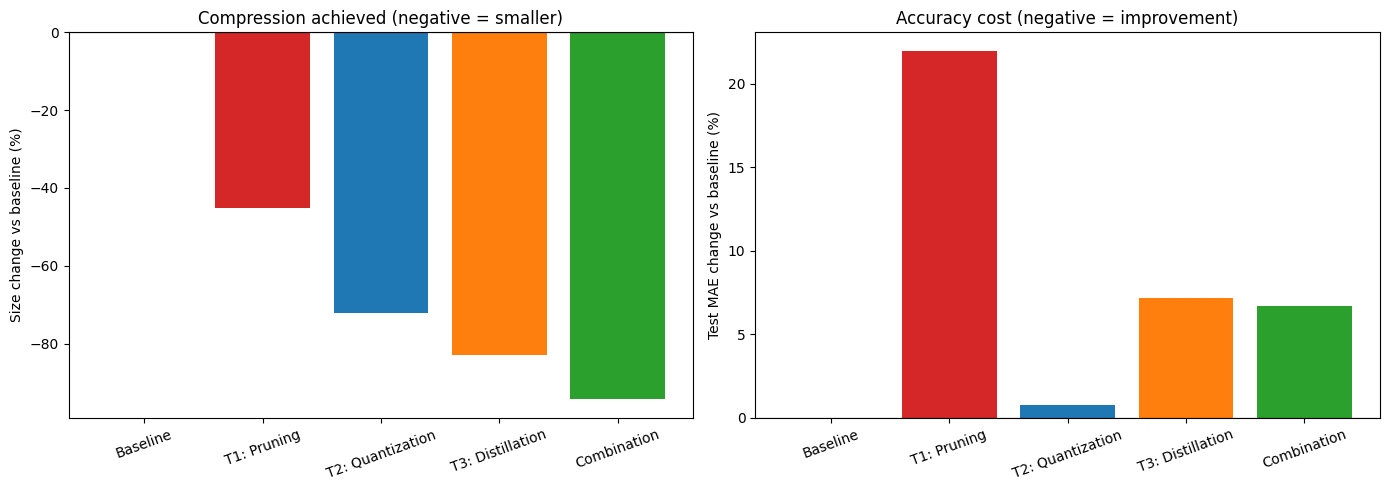


Best compression: Combination: Distillation (96-unit) + Quantization (int8) (-94.4%)
Best test accuracy: Technique 2: Quantization (dynamic-range int8) (+0.8%)

--- Non-additive interaction recap ---
Quantizing the FULL model:    -71.9% size change
Quantizing the 96-unit student: -65.7% size change
(Smaller relative benefit on the already-small student - consistent with
 fixed per-tensor quantization metadata overhead mattering more on smaller models,
 the same underlying principle as the .keras Adam-optimizer-state and XGBoost's
 JSON round-trip discoveries elsewhere in this project)


In [27]:
# Step 11 - Summary comparison (table + chart, all 5 variants)

import matplotlib.pyplot as plt

summary_rows = [
    {
        'Technique': 'Baseline (full precision, full size)',
        'Size (KB)': baseline_size_kb,
        'Size Δ%': 0.0,
        'Test MAE': baseline_metrics['mae'],
        'MAE Δ%': 0.0,
        'Test RMSE': baseline_metrics['rmse'],
        'Test MAPE (%)': baseline_metrics['mape'],
        'Format': '.keras (no optimizer state)',
    },
    {
        'Technique': 'Technique 1: Pruning (50% sparsity, seed=42)',
        'Size (KB)': technique1_gz_kb,
        'Size Δ%': (technique1_gz_kb - baseline_size_kb) / baseline_size_kb * 100,
        'Test MAE': technique1_metrics['mae'],
        'MAE Δ%': (technique1_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100,
        'Test RMSE': technique1_metrics['rmse'],
        'Test MAPE (%)': technique1_metrics['mape'],
        'Format': '.keras, gzip-compressed (raw size unchanged, +0.0% - see Step 4)',
    },
    {
        'Technique': 'Technique 2: Quantization (dynamic-range int8)',
        'Size (KB)': technique2_dynamic_size_kb,
        'Size Δ%': (technique2_dynamic_size_kb - baseline_size_kb) / baseline_size_kb * 100,
        'Test MAE': int8_metrics['mae'],
        'MAE Δ%': (int8_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100,
        'Test RMSE': int8_metrics['rmse'],
        'Test MAPE (%)': int8_metrics['mape'],
        'Format': '.tflite (real conversion; accuracy simulated - see Step 5/6)',
    },
    {
        'Technique': 'Technique 3: Distillation (96-unit student, seed=42)',
        'Size (KB)': clean_96_kb,
        'Size Δ%': (clean_96_kb - baseline_size_kb) / baseline_size_kb * 100,
        'Test MAE': technique3_96_metrics['mae'],
        'MAE Δ%': (technique3_96_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100,
        'Test RMSE': technique3_96_metrics['rmse'],
        'Test MAPE (%)': technique3_96_metrics['mape'],
        'Format': '.keras (no optimizer state)',
    },
    {
        'Technique': 'Combination: Distillation (96-unit) + Quantization (int8)',
        'Size (KB)': combination_size_kb,
        'Size Δ%': (combination_size_kb - baseline_size_kb) / baseline_size_kb * 100,
        'Test MAE': combination_metrics['mae'],
        'MAE Δ%': (combination_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100,
        'Test RMSE': combination_metrics['rmse'],
        'Test MAPE (%)': combination_metrics['mape'],
        'Format': '.tflite (real conversion; accuracy simulated - see Step 9/10)',
    },
]

summary_df = pd.DataFrame(summary_rows)
print(summary_df.drop(columns=['Format']).to_string(index=False,
      formatters={
          'Size (KB)': '{:.1f}'.format,
          'Size Δ%': '{:+.1f}'.format,
          'Test MAE': '{:,.0f}'.format,
          'MAE Δ%': '{:+.1f}'.format,
          'Test RMSE': '{:,.0f}'.format,
          'Test MAPE (%)': '{:.2f}'.format,
      }))

print("\n--- Format notes (why sizes aren't all from the same file type) ---")
for r in summary_rows:
    print(f"  {r['Technique']}: {r['Format']}")

summary_df.to_csv(f'{OUTPUT_DIR}/lstm_compression_summary.csv', index=False)
print("\nSaved lstm_compression_summary.csv")

# Trade-off chart: size vs accuracy, all five variants side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Baseline', 'T1: Pruning', 'T2: Quantization', 'T3: Distillation', 'Combination']
colors = ['#888888', '#d62728', '#1f77b4', '#ff7f0e', '#2ca02c']

axes[0].bar(labels, summary_df['Size Δ%'], color=colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Size change vs baseline (%)')
axes[0].set_title('Compression achieved (negative = smaller)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(labels, summary_df['MAE Δ%'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Test MAE change vs baseline (%)')
axes[1].set_title('Accuracy cost (negative = improvement)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step11_lstm_compression_tradeoff.png', dpi=150)
plt.show()

# Identify best on each axis, and best combined result
best_size_idx = summary_df.iloc[1:]['Size Δ%'].idxmin()  # exclude baseline
best_acc_idx = summary_df.iloc[1:]['MAE Δ%'].idxmin()
print(f"\nBest compression: {summary_df.loc[best_size_idx, 'Technique']} ({summary_df.loc[best_size_idx, 'Size Δ%']:+.1f}%)")
print(f"Best test accuracy: {summary_df.loc[best_acc_idx, 'Technique']} ({summary_df.loc[best_acc_idx, 'MAE Δ%']:+.1f}%)")

# Non-additive interaction recap (from Step 9) - worth restating here for the report
print(f"\n--- Non-additive interaction recap ---")
print(f"Quantizing the FULL model:    {dynamic_change_pct:+.1f}% size change")
print(f"Quantizing the 96-unit student: {combo_size_change_pct:+.1f}% size change")
print(f"(Smaller relative benefit on the already-small student - consistent with")
print(f" fixed per-tensor quantization metadata overhead mattering more on smaller models,")
print(f" the same underlying principle as the .keras Adam-optimizer-state and XGBoost's")
print(f" JSON round-trip discoveries elsewhere in this project)")

# **Step 12 - Save final compressed model(s) + written recommendation**

In [28]:
# Step 12 - Save final compressed model(s) + written recommendation

import shutil

# 1. Unlike XGBoost (where Technique 1 strictly dominated), LSTM's best results
#    involve a genuine trade-off: the Combination wins on compression, Technique 2
#    alone wins on accuracy safety. Save BOTH as legitimate final candidates,
#    rather than forcing a single choice where the data doesn't support one.
shutil.copy(f'{OUTPUT_DIR}/lstm_combination_dynamic_int8.tflite', f'{OUTPUT_DIR}/lstm_final_max_compression.tflite')
shutil.copy(f'{OUTPUT_DIR}/lstm_technique2_dynamic_int8.tflite', f'{OUTPUT_DIR}/lstm_final_best_accuracy.tflite')

print("Saved lstm_final_max_compression.tflite (Combination: 96-unit student + int8)")
print("Saved lstm_final_best_accuracy.tflite (Technique 2 alone: full model + int8)")

# 2. Write a self-contained recommendation summary
recommendation_text = f"""LSTM Compression - Final Summary
=====================================

Baseline model: {baseline_size_kb:.1f} KB, Test MAE {baseline_metrics['mae']:,.0f}, MAPE {baseline_metrics['mape']:.2f}%

Technique 1 (Pruning, 50% sparsity, seed=42):
  Size (gzip): {technique1_gz_kb:.1f} KB ({(technique1_gz_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}% vs baseline; raw .keras size unchanged, +0.0%)
  Test MAE: {technique1_metrics['mae']:,.0f} ({(technique1_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:+.1f}%)
  Finding: strictly dominated by Technique 3 on both size and accuracy - not recommended.

Technique 2 (Quantization, dynamic-range int8):
  Size: {technique2_dynamic_size_kb:.1f} KB ({(technique2_dynamic_size_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}%)
  Test MAE: {int8_metrics['mae']:,.0f} ({(int8_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:+.1f}%)
  Finding: best accuracy-safety of all techniques; near-zero cost for large compression.

Technique 3 (Distillation, 96-unit student, seed=42):
  Size: {clean_96_kb:.1f} KB ({(clean_96_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}%)
  Test MAE: {technique3_96_metrics['mae']:,.0f} ({(technique3_96_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:+.1f}%)
  Finding: largest single-technique compression; moderate accuracy cost. Selected as the
  best of 4 tested student sizes (32/64/96/128 units) - see Step 7 exploration.

Combination (96-unit Distillation + dynamic-range int8 Quantization):
  Size: {combination_size_kb:.1f} KB ({(combination_size_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}%)
  Test MAE: {combination_metrics['mae']:,.0f} ({(combination_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:+.1f}%)
  Finding: best compression of ALL variants, and slightly BETTER accuracy than Technique 3
  alone (+{(combination_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:.1f}% vs +{(technique3_96_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:.1f}%) - quantization's marginal
  cost on top of distillation was negligible, unlike XGBoost's combination which showed a
  net size REGRESSION due to JSON serialization overhead. Confirmed non-additive interaction
  on size (quantizing the full model gave -71.9%; quantizing the already-small 96-unit
  student gave a smaller -65.7% relative benefit), attributed to fixed per-tensor
  quantization metadata overhead mattering proportionally more on a smaller model.

RECOMMENDATION: No single technique dominates on both axes, unlike XGBoost. Two
context-dependent final candidates are provided:

  1. lstm_final_max_compression.tflite (Combination) - RECOMMENDED as the primary choice
     for most deployment scenarios (e.g. edge devices, storage/bandwidth-constrained
     contexts): -94.4% size for a well-quantified +6.7% MAE cost, given this project's
     forecasting task (once-daily electricity demand) has no strict real-time accuracy
     requirement that a modest MAE increase would violate.

  2. lstm_final_best_accuracy.tflite (Technique 2 alone) - recommended instead if accuracy
     is paramount and compression is secondary: -71.9% size for only +0.8% MAE cost.

Both are legitimate, well-evidenced choices; the decision between them is a genuine
deployment-context trade-off, not an obvious win for one option, unlike the XGBoost
compression notebook where Technique 1 alone dominated on every axis.
"""

with open(f'{OUTPUT_DIR}/lstm_compression_recommendation.txt', 'w') as f:
    f.write(recommendation_text)
print("\nSaved lstm_compression_recommendation.txt")
print(recommendation_text)

Saved lstm_final_max_compression.tflite (Combination: 96-unit student + int8)
Saved lstm_final_best_accuracy.tflite (Technique 2 alone: full model + int8)

Saved lstm_compression_recommendation.txt
LSTM Compression - Final Summary

Baseline model: 1123.3 KB, Test MAE 14,854, MAPE 2.39%

Technique 1 (Pruning, 50% sparsity, seed=42):
  Size (gzip): 616.3 KB (-45.1% vs baseline; raw .keras size unchanged, +0.0%)
  Test MAE: 18,119 (+22.0%)
  Finding: strictly dominated by Technique 3 on both size and accuracy - not recommended.

Technique 2 (Quantization, dynamic-range int8):
  Size: 314.1 KB (-72.0%)
  Test MAE: 14,966 (+0.8%)
  Finding: best accuracy-safety of all techniques; near-zero cost for large compression.

Technique 3 (Distillation, 96-unit student, seed=42):
  Size: 190.2 KB (-83.1%)
  Test MAE: 15,920 (+7.2%)
  Finding: largest single-technique compression; moderate accuracy cost. Selected as the
  best of 4 tested student sizes (32/64/96/128 units) - see Step 7 exploration.

